<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day2/ExerciseXP/ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [1]:
import pandas as pd
import requests
import zipfile
import io

# Charger le dataset depuis GitHub
url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%204/Day%202/Diabetes%20prediction%20dataset.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
df = pd.read_csv(z.open(z.namelist()[0]))

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [2]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
] if cat_cols else [
    ('num', StandardScaler(), num_cols)
])

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


## Exercise 3 - Model training

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ('preprocessing', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

clf.fit(X_train, y_train)
print(" Modèle entraîné avec succès !")

✅ Modèle entraîné avec succès !



## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy  : 0.9589
Precision : 0.8632
Recall    : 0.6171
F1-Score  : 0.7197


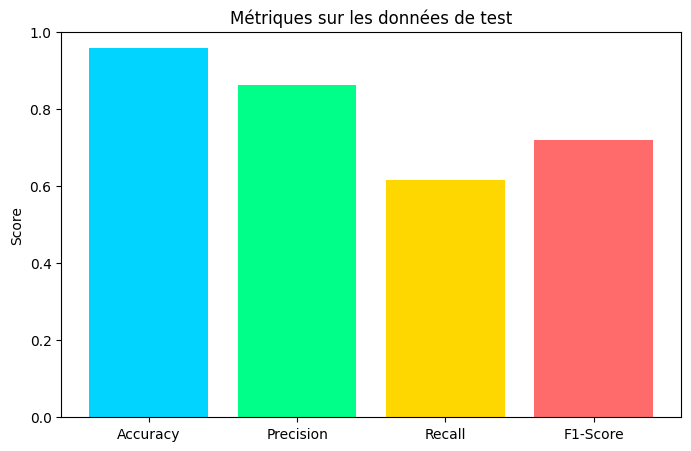

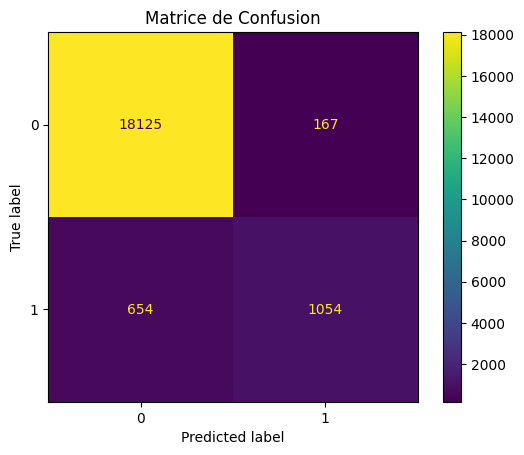

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1-Score  :", round(f1, 4))

# Graphique des métriques
plt.figure(figsize=(8, 5))
plt.bar(
    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    [acc, prec, rec, f1],
    color=['#00D4FF', '#00FF88', '#FFD700', '#FF6B6B']
)
plt.title('Métriques sur les données de test')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Matrice de Confusion')
plt.show()

### Commentaire sur les métriques

- **Accuracy : 0.9589** → Le modèle prédit correctement 95.89% des cas
  Attention : données déséquilibrées (91% non diabétiques) donc
  l'accuracy seule n'est pas suffisante !

- **Precision : 0.8632** → Quand le modèle dit "diabétique",
  il a raison 86% du temps → peu de faux positifs

- **Recall : 0.6171** → Le modèle détecte seulement 61% des vrais
  diabétiques → trop de faux négatifs

- **F1-Score : 0.7197** → Équilibre moyen entre Precision et Recall

### Conclusion
Le Recall est trop faible (0.62) pour un problème médical.
Le modèle rate 38% des vrais diabétiques ce qui est dangereux !

Solutions possibles :
- Rééquilibrer les classes (SMOTE, class_weight='balanced')
- Ajuster le seuil de décision (threshold < 0.5)
- Essayer Random Forest ou XGBoost


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


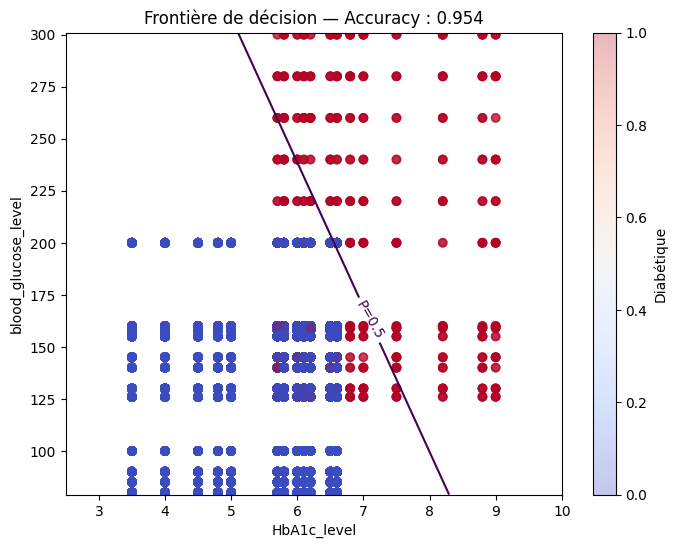

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

feat_x = 'HbA1c_level'
feat_y = 'blood_glucose_level'

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test  = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
probs = pipe2.predict_proba(
    np.c_[xx.ravel(), yy.ravel()]
)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 6))
cs = plt.contour(xx, yy, probs, levels=[0.5])
plt.clabel(cs, inline=True, fmt={0.5: 'P=0.5'})
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.3, cmap='coolwarm')
plt.xlabel(feat_x)
plt.ylabel(feat_y)
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Frontière de décision — Accuracy : {acc2:.3f}')
plt.colorbar(label='Diabétique')
plt.show()


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


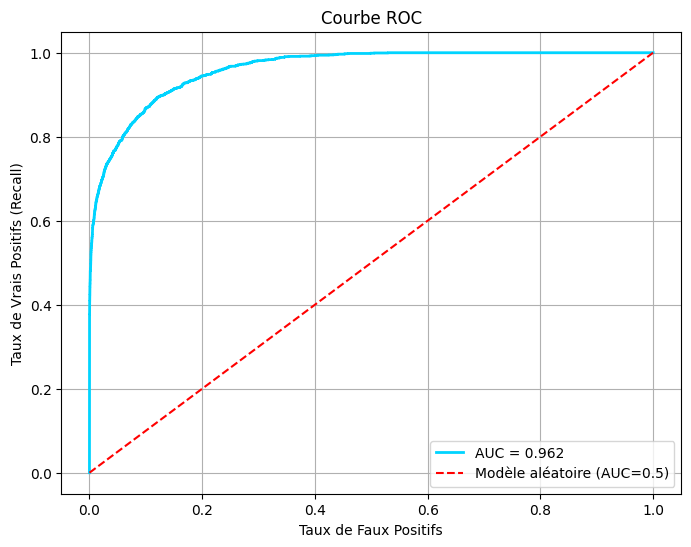

AUC-ROC : 0.9617


In [9]:
from sklearn import metrics
import matplotlib.pyplot as plt

y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#00D4FF', linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', label='Modèle aléatoire (AUC=0.5)')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.xlabel('Taux de Faux Positifs')
plt.title('Courbe ROC')
plt.legend(loc=4)
plt.grid(True)
plt.show()

print(f"AUC-ROC : {auc:.4f}")

### Interprétation de la Courbe ROC — AUC : 0.9617

**AUC = 0.9617 → Excellent modèle !**

| Valeur AUC | Interprétation |
|---|---|
| 1.0 | Modèle parfait |
| 0.96 | Notre modèle  |
| > 0.9 | Excellent |
| > 0.8 | Bon |
| 0.5 | Modèle aléatoire |

### Analyse
- La courbe ROC s'éloigne fortement de la diagonale rouge
  → le modèle est bien meilleur qu'un modèle aléatoire
- AUC = 0.96 signifie que le modèle distingue correctement
  les diabétiques des non-diabétiques dans 96% des cas
- Malgré un Recall faible (0.62), l'AUC reste excellent
  car il mesure la capacité globale de discrimination

### Conclusion générale
- Accuracy : 0.9589
- Precision : 0.8632
- Recall    : 0.6171  à améliorer
- F1-Score  : 0.7197
- AUC-ROC   : 0.9617

Le modèle est très performant mais le Recall doit être amélioré
pour un usage médical réel — on rate encore 38% des diabétiques !